# Task 5 — Addestramento di più classificatori con Scikit-Learn


In questo notebook vengono addestrati e confrontati diversi classificatori mediante la libreria **Scikit-Learn**. L'obiettivo è separare opportunamente i campioni in training e test set, **massimizzare le prestazioni sul test set** e selezionare infine il modello migliore.

I cinque classificatori considerati sono: **Naïve Bayes**, **Regressione logistica**, **Albero di decisione**, **k-NN** e **Percettrone**.

# 1. Caricamento del dataset

Carichiamo il dataset pulito `training.csv` prodotto dal **Task 1** . Il punto su cui concentrarsi è la **distribuzione del target**: la classe positiva (`y = 1`, cliente che sottoscrive) è una netta minoranza (~11%). Questo **sbilanciamento** è il filo conduttore di tutte le scelte successive.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 10
np.random.seed(SEED)
pd.set_option("display.max_columns", None)

training_df = pd.read_csv("../data/processed/training.csv", sep=";")
print("Dimensioni:", training_df.shape)
print("\nProporzione classe positiva 'yes':",
      round(training_df["y"].mean() * 100, 2), "%")
training_df.head()

Dimensioni: (41176, 20)

Proporzione classe positiva 'yes': 11.27 %


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


# 2. Preparazione dei dati

Separo le features dal target , escludendo **`pdays`** per le considerazioni fatte nel task 3 .

Le feature **nominali** sono stringhe e vanno convertite in forma numerica (one-hot encoding), mentre quelle numeriche vanno standardizzate: lo facciamo nella **sezione 4**, una sola volta, adattando le trasformazioni solo sul training. Non applichiamo invece la **discretizzazione**, perché gli algoritmi di Scikit-Learn gestiscono direttamente gli attributi continui .

In [24]:
X = training_df.drop(columns=["y","pdays"], errors="ignore")
y = training_df["y"]

print("Numero di feature:", X.shape[1])
print("Colonne:", list(X.columns))

Numero di feature: 18
Colonne: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


# 3. Separazione tra Training set e Test Set

Il dataset viene suddiviso in **70% training** e **30% test** con suddivisione **stratificata** (`stratify=y`), per preservare la proporzione delle classi nei due sottoinsiemi. Questo è particolarmente importante in presenza di dataset sbilanciati: senza stratificazione il test potrebbe contenere troppo pochi esempi positivi per una stima affidabile. Il test set viene messo da parte e usato solo per la valutazione finale.

In [25]:
from sklearn.model_selection import train_test_split

X_addestramento, X_test, y_addestramento, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

print("Training set:", X_addestramento.shape[0], "campioni")
print("Test set:    ", X_test.shape[0], "campioni")
print("Proporzione 'yes' — train:", round(y_addestramento.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Training set: 28823 campioni
Test set:     12353 campioni
Proporzione 'yes' — train: 0.1127 | test: 0.1127


# 4. Preprocessing delle feature

Le feature **nominali** (`job`, `marital`, `education`, ...) sono stringhe e i classificatori di Scikit-Learn lavorano solo su valori numerici; inoltre i modelli sensibili alla scala (Regressione logistica, k-NN, Percettrone) richiedono feature **standardizzate**. Usiamo un `ColumnTransformer` che applica:

- alle feature **numeriche** → `StandardScaler`;
- alle feature **nominali** → `OneHotEncoder` (`handle_unknown="ignore"`, per gestire eventuali categorie nuove nel test o in `real_settings.csv`).

Applichiamo la trasformazione **una sola volta**: la adattiamo (`fit`) solo sul training e la riapplichiamo (`transform`) al test, ottenendo le matrici numeriche `X_addestramento_enc` e `X_test_enc` da passare **direttamente** ai classificatori — senza incapsularli in una pipeline. Adattare il preprocessing solo sul training evita il *data leakage*.

> Nota: dalla **sezione 7** (cross-validation e, a seguire, tuning) lo stesso `preprocessor` viene invece inserito in una `Pipeline` con il classificatore, così da essere ri-adattato dentro ogni fold — l'unico modo corretto di validare senza leakage.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

colonne_numeriche = X.select_dtypes(include="number").columns.tolist()
colonne_nominali  = X.select_dtypes(exclude="number").columns.tolist()

# Le feature nominali sono stringhe: le codifico in numerico (one-hot) e
# standardizzo quelle numeriche. Il preprocessore viene ADATTATO solo sul
# training e poi applicato al test, per non introdurre data leakage.
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), colonne_numeriche),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), colonne_nominali),
])

X_addestramento_enc = preprocessor.fit_transform(X_addestramento)
X_test_enc          = preprocessor.transform(X_test)

# Alias usati dalla sezione 8 in poi (cross-validation con Pipeline sui dati grezzi)
X_train, y_train = X_addestramento, y_addestramento

print("Feature numeriche:", colonne_numeriche)
print("Feature nominali: ", colonne_nominali)
print("Shape dopo encoding — train:", X_addestramento_enc.shape,
      "| test:", X_test_enc.shape)

Feature numeriche: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Feature nominali:  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Shape dopo encoding — train: (28823, 55) | test: (12353, 55)


# 5. Addestramento dei classificatori

 In linea con l'analisi sullo sbilanciamento, la metrica guida è la **F1-score sulla classe positiva** (media armonica di precision e recall), affiancata da precision, recall e accuratezza.


L'ordine delle sezioni è:

- **5.1** Naïve Bayes
- **5.2** Regressione logistica
- **5.3** Albero di decisione
- **5.4** k-NN
- **5.5** Percettrone

## 5.1 Naïve Bayes

In [27]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_addestramento_enc, y_addestramento)
nb_predetto = nb.predict(X_test_enc)

## Valutazione


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [29]:
risultati = []

risultati.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_predetto),
    "Precision": precision_score(y_test, nb_predetto),
    "Recall": recall_score(y_test, nb_predetto),
    "F1": f1_score(y_test, nb_predetto)
})

### Discussione

I numeri raccontano subito il carattere del modello: **recall 0.764** (la più alta di tutti) ma **precision 0.198** (la più bassa). In pratica Naïve Bayes dice `yes` a moltissimi clienti: così intercetta quasi tutti quelli realmente interessati, ma annega il risultato in una marea di falsi allarmi. L'**accuratezza (0.624)** è l'unica a scendere addirittura **sotto il baseline** "sempre no" (0.887), e la **F1 si ferma a 0.314**.

In sintesi è un classificatore "generoso": preferisce sbagliare proponendo un cliente in più piuttosto che lasciarne scappare uno. Questo profilo — tanta copertura, poca precisione — è lo stesso già visto applicando il modello a mano nei Task 2 e 4, quindi è una caratteristica del metodo e non un caso isolato.

> Nota metodologica: per attributi categorici sarebbe più adatto un `CategoricalNB`, ma per usare la stessa pipeline degli altri quattro modelli si è scelto `GaussianNB` sull'intera matrice one-hot, accettandone consapevolmente i limiti.

## 5.2 Regressione logistica

La regressione logistica è un **modello lineare** per la classificazione e, a differenza della regressione lineare, non predice un valore continuo ma la **probabilità di appartenenza** a una determinata classe.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$


In [30]:
from sklearn.linear_model import LogisticRegression

regressioneLineare = LogisticRegression(class_weight="balanced",
                                        max_iter=1000, random_state=SEED)
regressioneLineare.fit(X_addestramento_enc, y_addestramento)
regressioneLineare_predetto = regressioneLineare.predict(X_test_enc)

## Valutazione

In [31]:
risultati.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, regressioneLineare_predetto),
    "Precision": precision_score(y_test, regressioneLineare_predetto),
    "Recall": recall_score(y_test, regressioneLineare_predetto),
    "F1": f1_score(y_test, regressioneLineare_predetto)
})

### Discussione

La regressione logistica raggiunge il **secondo risultato migliore**, subito dietro l'albero: **F1 0.458**, con **recall 0.634** e **precision 0.358**. È un equilibrio sano e in linea con l'obiettivo della campagna: individua circa due terzi dei clienti interessati, accettando in cambio un numero ragionevole di proposte a vuoto.

L'**accuratezza (0.831)** resta sotto il baseline, ma è un prezzo voluto: grazie a `class_weight="balanced"` il modello dà più peso alla classe rara invece di limitarsi a predire `no` per "fare punti" sull'accuratezza.

Un vantaggio pratico è che la logistica non assegna direttamente la classe ma stima una **probabilità**: abbassando la soglia decisionale si può spostare ancora di più il bilanciamento verso la recall, **senza riaddestrare**. Come vedremo nella sezione 8, però, ritoccare i suoi iperparametri cambia pochissimo i risultati: il modello è già vicino al massimo che i dati consentono.

## 5.3 Albero di decisione

Gli alberi decisionali suddividono progressivamente il dataset in sottoinsiemi sempre più omogenei rispetto al target, scegliendo a ogni nodo la feature che massimizza la separazione tra le classi (Lezione 6). Sono molto interpretabili e possono essere tradotti in regole IF-THEN. Usiamo `class_weight="balanced"` per contrastare lo sbilanciamento e limitiamo la profondità per evitare overfitting.

In [32]:
from sklearn.tree import DecisionTreeClassifier

alberoDecisionale = DecisionTreeClassifier(max_depth=5,
                                           class_weight="balanced",
                                           random_state=SEED)
alberoDecisionale.fit(X_addestramento_enc, y_addestramento)
alberoDecisionale_predetto = alberoDecisionale.predict(X_test_enc)

## Valutazione

In [33]:
risultati.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, alberoDecisionale_predetto),
    "Precision": precision_score(y_test, alberoDecisionale_predetto),
    "Recall": recall_score(y_test, alberoDecisionale_predetto),
    "F1": f1_score(y_test, alberoDecisionale_predetto)
})

### Discussione

L'albero è il **miglior modello** di questa sezione: **F1 0.492**, con **recall 0.561** e **precision 0.439**. È il **compromesso più equilibrato** tra i due tipi di errore — non eccelle in una singola metrica come Naïve Bayes o k-NN, ma è quello che sbaglia meno "da entrambe le parti". La cross-validation (sezione 7) lo conferma in testa alla classifica con **F1 media 0.473**.

Il suo punto di forza è la capacità di combinare più condizioni in cascata (del tipo "se l'indicatore occupazionale è basso **e** l'esito della campagna precedente è positivo, allora..."), cogliendo legami che un modello lineare non riesce a rappresentare. La profondità è volutamente limitata (`max_depth=5`) per due motivi: tenere il modello **leggibile** come poche regole IF-THEN e **non farlo adattare troppo** ai dati di addestramento.

L'unico neo è che un singolo albero è un po' "ballerino": in cross-validation la sua variabilità tra i fold (±0.031) è la più alta tra i modelli di testa, contro ±0.015 della logistica. Il tuning della sezione 8 confermerà comunque che `max_depth=5` è già la scelta giusta.

## 5.4 k-Nearest Neighbors (k-NN)

Il k-NN appartiene ai metodi **instance-based** (Lezione 7): per classificare una nuova osservazione individua i `k` campioni più vicini nel training set e assegna la classe più frequente tra essi. La vicinanza si misura con una distanza (euclidea), perciò il modello è addestrato sui dati **standardizzati** dalla pipeline. k-NN non dispone di `class_weight`.

In [34]:
from sklearn.neighbors import KNeighborsClassifier

k = 31

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_addestramento_enc, y_addestramento)
knn_predetto = knn.predict(X_test_enc)

## Valutazione

In [35]:
risultati.append({
    "Model": "k-NN",
    "Accuracy": accuracy_score(y_test, knn_predetto),
    "Precision": precision_score(y_test, knn_predetto),
    "Recall": recall_score(y_test, knn_predetto),
    "F1": f1_score(y_test, knn_predetto)
})

### Discussione

Il k-NN è l'esatto opposto del Naïve Bayes: ha la **precision più alta** di tutti (**0.602**) ma una **recall molto bassa** (**0.234**), per una **F1 di 0.336**. Detto in parole semplici: quando dice `yes` ci azzecca spesso, ma se ne lascia scappare circa tre quarti dei clienti realmente interessati.

Il motivo è intuitivo. Il modello classifica ogni cliente guardando i 31 casi più simili e assegnando la classe **più frequente** tra loro. Ma siccome i clienti che sottoscrivono sono solo l'~11%, è raro che siano la maggioranza in un gruppo di vicini: quasi sempre vince `no`. Da qui la recall così bassa. È un classificatore **prudente**, che conferma `yes` solo quando è praticamente circondato da altri `yes`.

Va segnalato anche un aspetto pratico: il k-NN non impara nulla in fase di addestramento, ma a ogni predizione confronta il cliente con tutti i quasi 29.000 esempi di training, quindi è il più **lento** a fare previsioni. Nella sezione 8 proveremo a stringere il vicinato per recuperare un po' di recall, ma il modello resterà comunque sbilanciato verso la precision e poco adatto, da solo, a una campagna che punta alla copertura.

## 5.5 Percettrone

Il percettrone è uno dei più semplici algoritmi per la **classificazione lineare** (Lezione 7): apprende iterativamente un iperpiano di separazione aggiornando i pesi quando commette un errore. Dipende dai valori numerici delle feature, quindi anch'esso usa i dati standardizzati della pipeline, e supporta `class_weight="balanced"`.

In [36]:
from sklearn.linear_model import Perceptron

perceptron = Perceptron(class_weight="balanced",
                        max_iter=1000, random_state=SEED)
perceptron.fit(X_addestramento_enc, y_addestramento)
perceptron_predetto = perceptron.predict(X_test_enc)

## Valuzione

In [37]:
risultati.append({
    "Model": "Perceptron",
    "Accuracy": accuracy_score(y_test, perceptron_predetto),
    "Precision": precision_score(y_test, perceptron_predetto),
    "Recall": recall_score(y_test, perceptron_predetto),
    "F1": f1_score(y_test, perceptron_predetto)
})

### Discussione

Il percettrone è il **modello meno performante**: **F1 0.295**, con recall 0.284 e precision 0.307. Non eccelle in nessuna metrica e, soprattutto, è il **meno affidabile**: in cross-validation cambia molto da un fold all'altro (variabilità **±0.067**, oltre quattro volte quella della logistica).

Questa instabilità ha una spiegazione semplice: il percettrone funziona bene solo quando le due classi si possono separare con una linea netta, cosa che qui non accade. Di conseguenza continua a "correggersi" senza mai assestarsi davvero, e il risultato finale dipende anche dall'ordine in cui vede i dati — da cui i valori così altalenanti.

Vale la pena confrontarlo con la regressione logistica, che è il suo "parente" lineare ma molto più solido: a parità di confine lineare, la logistica vince nettamente perché stima probabilità (e quindi una soglia regolabile) ed è più stabile. Proprio per questi motivi il percettrone **non viene incluso** tra i modelli ottimizzati nella sezione 8.

# 6. Confronto dei risultati

Raccogliamo le prestazioni di tutti i classificatori in un'unica tabella, ordinata per **F1 sulla classe positiva**. Poiché il dataset è sbilanciato, non guardiamo l'accuratezza ma precision, recall e soprattutto F1, che misurano la reale capacità di individuare i clienti interessati.

In [38]:
results_df = (pd.DataFrame(risultati)
              .sort_values("F1", ascending=False)
              .reset_index(drop=True))
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8696,0.4385,0.5611,0.4923
1,Logistic Regression,0.8307,0.3582,0.6343,0.4579
2,k-NN,0.8962,0.6019,0.2335,0.3364
3,Naive Bayes,0.6241,0.1978,0.7644,0.3143
4,Perceptron,0.8472,0.3072,0.2838,0.2950


### Confronto visuale: F1 vs Accuracy

Il grafico contrappone, per ogni modello, la **F1 sulla minoranza** e l'**accuratezza**, con la linea del baseline "sempre no". È la dimostrazione visiva del problema: alcuni modelli hanno accuratezza inferiore al baseline ma F1 molto più alta, perché individuano davvero i positivi invece di limitarsi a predire la classe maggioritaria.

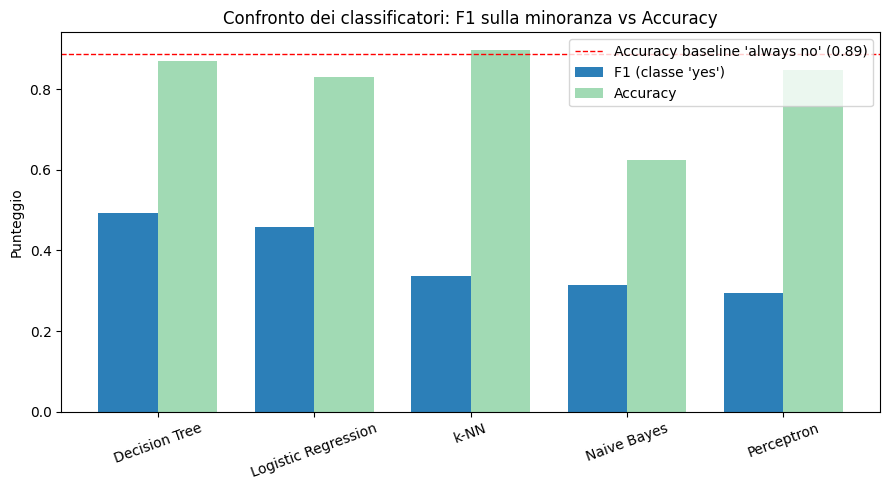

In [39]:
baseline_acc = 1 - y_test.mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
w = 0.38
ax.bar(x - w/2, results_df["F1"], w, label="F1 (classe 'yes')", color="#2c7fb8")
ax.bar(x + w/2, results_df["Accuracy"], w, label="Accuracy", color="#a1dab4")
ax.axhline(baseline_acc, color="red", linestyle="--", linewidth=1,
           label=f"Accuracy baseline 'always no' ({baseline_acc:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20)
ax.set_ylabel("Punteggio")
ax.set_title("Confronto dei classificatori: F1 sulla minoranza vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## Discussione critica dei risultati

La tabella va letta lungo l'asse **precision / recall**: ogni modello sceglie, implicitamente, *come* sbagliare. I cinque classificatori si dispongono lungo tutto questo spettro.

**I due estremi.**

- **Naïve Bayes** punta tutto sulla **recall** (0.764, la più alta) sacrificando la precision (0.198, la più bassa): intercetta quasi tutti i clienti propensi ma sommerge il risultato di falsi allarmi. È l'unico modello con accuratezza (0.624) **sotto il baseline** "sempre no" (0.887).
- **k-NN** è il suo specchio: **precision** massima (0.602) ma recall minima (0.234). È prudente — quando dice `yes` ci azzecca — ma lascia scappare i tre quarti dei propensi, perché il vicinato è dominato dalla classe maggioritaria.

**La fascia bilanciata.** **Albero, Regressione logistica** e (più debolmente) **Percettrone**, grazie a `class_weight="balanced"`, recuperano recall mantenendo una precision sostenibile: è il **trade-off desiderato** per una campagna di marketing, dove perdere un cliente interessato (falso negativo) costa più di una telefonata a vuoto (falso positivo).

**La sintesi: F1.** La media armonica di precision e recall premia chi bilancia i due errori e penalizza gli estremi (infatti Naïve Bayes e k-NN, pur eccellendo su una sola metrica, hanno F1 bassa). La classifica che ne emerge è:

| Posizione | Modello | F1 | Lettura |
|---|---|---|---|
| 1° | **Albero di decisione** | **0.492** | miglior equilibrio (P 0.44 / R 0.56) |
| 2° | **Regressione logistica** | 0.458 | più orientato alla recall (P 0.36 / R 0.63) |
| 3° | k-NN | 0.336 | troppo conservativo |
| 4° | Naïve Bayes | 0.314 | troppi falsi allarmi |
| 5° | Percettrone | 0.295 | lineare "duro", instabile |

**L'accuratezza conferma la sua inaffidabilità.** Il caso più eclatante è proprio il k-NN: ha l'**accuratezza più alta** (0.896, l'unico sopra il baseline) ma una F1 modesta, perché "vince" semplicemente assecondando la classe maggioritaria. All'opposto, i due modelli con la F1 migliore (Albero e Logistica) hanno accuratezza **inferiore** al baseline. È la dimostrazione numerica del principio guida del progetto: su dati sbilanciati l'accuratezza misura il conformismo, non la capacità di individuare la classe rara.

**Conclusione di sezione.** **Albero** e **Regressione logistica** sono i due candidati seri; il Percettrone, lineare ma privo della loss probabilistica e regolarizzata della logistica, ne è una versione più debole e meno stabile. Questi esiti dell'holdout vanno però confermati su una stima più robusta: è il compito della **cross-validation** (sezione 7), che verificherà se l'ordine regge cambiando la suddivisione dei dati.

# 7. Cross Validation

La valutazione holdout dipende dalla particolare suddivisione casuale dei dati. Per una stima più robusta applichiamo una **Stratified 10-Fold Cross Validation** (Lezione 9): il training set viene diviso in 10 fold mantenendo la proporzione delle classi; a turno un fold fa da validazione e gli altri nove da addestramento, e si media la F1. La eseguiamo **solo sul training set**, senza toccare il test.

Rispetto a una 5-fold, la 10-fold addestra ogni modello su una frazione maggiore dei dati (~90% invece dell'80%), riducendo il *bias* della stima; in cambio richiede il doppio degli addestramenti ed è quindi più onerosa. Con quasi 29.000 campioni di training il costo resta sostenibile e la stima della F1 risulta più affidabile.

Per evitare la ripetizione di codice modello-per-modello, raccogliamo i cinque classificatori in un dizionario e applichiamo la cross-validation in modo **vettoriale** con `Series.apply`, nel rispetto del vincolo di stile del progetto (nessun ciclo `for` esplicito).

In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# Dizionario {nome: pipeline completa}
classificatori = {
    "Naive Bayes":         Pipeline([("prep", preprocessor), ("clf", GaussianNB())]),
    "Logistic Regression": Pipeline([("prep", preprocessor),
                                     ("clf", LogisticRegression(class_weight="balanced",
                                             max_iter=1000, random_state=SEED))]),
    "Decision Tree":       Pipeline([("prep", preprocessor),
                                     ("clf", DecisionTreeClassifier(max_depth=5,
                                             class_weight="balanced", random_state=SEED))]),
    "k-NN":                Pipeline([("prep", preprocessor),
                                     ("clf", KNeighborsClassifier(n_neighbors=31))]),
    "Perceptron":          Pipeline([("prep", preprocessor),
                                     ("clf", Perceptron(class_weight="balanced",
                                             max_iter=1000, random_state=SEED))]),
}

def cv_di(nome):
    scores = cross_val_score(classificatori[nome], X_train, y_train,
                             cv=cv, scoring="f1")
    return pd.Series({"Model": nome,
                      "CV_F1_Mean": scores.mean(),
                      "CV_F1_Std": scores.std()})

cv_results = (pd.Index(list(classificatori.keys())).to_series()
              .apply(cv_di)
              .sort_values("CV_F1_Mean", ascending=False)
              .reset_index(drop=True))
cv_results.round(4)

,Model,CV_F1_Mean,CV_F1_Std
0,Decision Tree,0.4729,0.0310
1,Logistic Regression,0.4533,0.0149
2,k-NN,0.3320,0.0311
3,Naive Bayes,0.3186,0.0051
4,Perceptron,0.2928,0.0673


## Analisi dei risultati della Cross Validation

La cross-validation fa due cose: **conferma** la classifica emersa dall'holdout e aggiunge una dimensione che la singola suddivisione non poteva dare — la **stabilità** di ogni modello, misurata dalla deviazione standard della F1 tra i 10 fold. Si legge quindi su due assi: *quanto* è bravo un modello (media) e *quanto è affidabile* quel giudizio (dispersione).

**L'ordine regge.** La graduatoria è identica a quella dell'holdout: **Albero** (0.473) davanti a **Regressione logistica** (0.453), poi k-NN (0.332), Naïve Bayes (0.319) e Percettrone (0.293). Il fatto che la classifica non cambi cambiando la partizione dei dati è di per sé un risultato: gli esiti della sezione 6 **non erano un artefatto** di quella particolare suddivisione casuale. Le medie sono inoltre quasi identiche a quelle che si otterrebbero con una 5-fold, segno che la stima è ormai **robusta** rispetto al numero di fold.

**La stabilità racconta una storia in più.** Confrontando le deviazioni standard:

| Modello | F1 media (CV) | Dev. std | Lettura |
|---|---|---|---|
| Albero di decisione | 0.473 | ±0.031 | migliore in media, ma varianza non trascurabile |
| Regressione logistica | 0.453 | **±0.015** | quasi pari all'albero e **il più stabile tra i modelli di testa** |
| k-NN | 0.332 | ±0.031 | — |
| Naïve Bayes | 0.319 | ±0.005 | la dispersione più bassa in assoluto, ma su un livello di F1 mediocre |
| Percettrone | 0.293 | **±0.067** | ultimo e **di gran lunga il più instabile** |

Due osservazioni rilevanti per la scelta finale:

- **Albero vs Logistica.** L'albero ha la media più alta, ma la logistica è in pratica appaiata (Δ ≈ 0.020) ed è **circa il doppio più stabile** (±0.015 contro ±0.031). Tenendo conto della dispersione, gli intervalli si sovrappongono ampiamente: il vantaggio dell'albero è reale ma **non schiacciante**, e questo giustifica il fatto di portarli **entrambi** al tuning della sezione 8 invece di scartare subito il secondo.
- **Percettrone.** La sua deviazione standard (±0.067) è oltre **4 volte** quella della logistica: la conferma quantitativa della sua instabilità di modello lineare "duro", che non converge su dati non linearmente separabili. Una F1 così ballerina lo rende inaffidabile a prescindere dalla media.

> Nota sul passaggio a 10 fold: rispetto a una 5-fold, ogni fold di validazione è più piccolo (~10% del training), quindi la F1 stimata su ciascuno è leggermente più "rumorosa" e le deviazioni standard tendono a salire (lo si vede su Albero, k-NN e logistica); in cambio l'addestramento avviene su una frazione maggiore di dati (~90%), riducendo il *bias* della stima della media.

**Assenza di overfitting.** Per i modelli di testa la F1 in CV è molto vicina a quella ottenuta sul test (es. albero 0.473 in CV vs 0.492 sul test; logistica 0.453 vs 0.458): lo scarto è minimo e, se mai, l'holdout è stato leggermente *ottimista*, non il contrario. La coerenza tra le due stime indica che non c'è overfitting sui dati di addestramento. Restano da **ottimizzare gli iperparametri** (sezione 8) per spremere l'ultimo margine dai due candidati migliori.

# 8. Ottimizzazione degli iperparametri

I modelli precedenti usano parametri ragionevoli ma fissati a mano. In questa sezione ottimizziamo gli iperparametri tramite **`GridSearchCV`** (stessa cross-validation stratificata a 10 fold della sezione 7, scoring **F1** sulla classe positiva) sui tre modelli che hanno mostrato maggiore potenziale o che dipendono da iperparametri sensibili:

- **Regressione logistica** — `C` (inverso dell'intensità della regolarizzazione): `[0.01, 0.1, 1.0, 10.0, 100.0]`, per esplorare sia una regolarizzazione forte sia debole;
- **Albero di decisione** — `max_depth` `[3, 5, 7, 10, None]` 
- **k-NN** — `n_neighbors` `[15, 31, 51]`.

Naïve Bayes e Percettrone sono **esclusi**: il primo non ha iperparametri che modifichino sostanzialmente il trade-off precision/recall su questa matrice one-hot, il secondo è già risultato il modello più debole e instabile (sezione 7).

L'obiettivo è migliorare le prestazioni rispetto alla configurazione iniziale e, soprattutto, **capire dove** il margine di guadagno è reale e dove è esaurito. Anche qui evitiamo cicli espliciti: le tre ricerche sono organizzate in un dizionario `{nome: (pipeline, griglia)}` e lanciate con `Series.apply`. La cross-validation gira **solo sul training**; il test set resta intatto e serve unicamente come stima finale e imparziale del modello già selezionato.

In [41]:
from sklearn.model_selection import GridSearchCV

grids = {
    "Logistic Regression": (
        Pipeline([("prep", preprocessor),
                  ("clf", LogisticRegression(class_weight="balanced",
                          max_iter=1000, random_state=SEED))]),
        {"clf__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    "Decision Tree": (
        Pipeline([("prep", preprocessor),
                  ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))]),
        {"clf__max_depth": [3, 5, 7, 10, None]},),
    "k-NN": (
        Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [15, 31, 51]},),
}

def tuning_di(nome):
    pipe, griglia = grids[nome]
    search = GridSearchCV(pipe, griglia, scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    pred = search.best_estimator_.predict(X_test)
    return pd.Series({
        "Model": nome,
        "Best_params": str(search.best_params_),
        "CV_F1": search.best_score_,
        "Test_F1": f1_score(y_test, pred),
        "Test_Recall": recall_score(y_test, pred),
        "Test_Precision": precision_score(y_test, pred, zero_division=0),
        "_estimator": search.best_estimator_,
        "_pred": pred,
    })

tuning = (pd.Index(list(grids.keys())).to_series()
          .apply(tuning_di)
          .reset_index(drop=True))

tuning.drop(columns=["_estimator", "_pred"]).round(4)

,Model,Best_params,CV_F1,Test_F1,Test_Recall,Test_Precision
0,Logistic Regression,{'clf__C': 100.0},0.4540,0.4575,0.6336,0.3580
1,Decision Tree,{'clf__max_depth': 5},0.4729,0.4923,0.5611,0.4385
2,k-NN,{'clf__n_neighbors': 15},0.3497,0.3526,0.2536,0.5787


### Analisi dell'ottimizzazione

Il tuning va letto su due piani: **quanto** ogni modello guadagna rispetto alla configurazione iniziale (sezione 5) e, soprattutto, **cosa ci dice** la scelta degli iperparametri sulla natura del problema. Il confronto prima/dopo è il seguente (F1 sulla classe positiva):

| Modello | Config. iniziale (sez. 5) | F1 CV → | F1 test → | Config. ottimizzata | F1 CV | F1 test |
|---|---|---|---|---|---|---|
| **Albero di decisione** | `max_depth=5` | 0.473 | 0.492 | `max_depth=5` | **0.473** | **0.492** |
| **Regressione logistica** | `C=1.0` | 0.453 | 0.458 | `C=100.0` | 0.454 | 0.458 |
| **k-NN** | `k=31` | 0.332 | 0.336 | `k=15` | 0.350 | 0.353 |

**Albero di decisione — la profondità scelta a mano era già quella ottimale.** La grid esplora `max_depth ∈ {3, 5, 7, 10, None}` e riseleziona esattamente **`max_depth=5`**, lo stesso valore già usato nella sezione 5: i risultati restano quindi identici (CV 0.473, test 0.492). È un esito significativo: alberi più profondi (`7`, `10`, `None`) si adattano meglio al training ma non generalizzano, mentre `max_depth=3` è troppo rigido. La scelta iniziale era insomma già nel punto giusto del compromesso *bias/varianza*, e non c'è margine ulteriore da spremere sulla profondità.

**Regressione logistica — `C` è quasi irrilevante: siamo al tetto informativo dei dati.** Nonostante la griglia copra cinque ordini di grandezza (`C ∈ {0.01, …, 100}`, cioè da regolarizzazione molto forte a molto debole), la F1 in CV si muove di pochi millesimi e si assesta a **0.454** con `C=100`; sul test resta **0.458**, identica alla configurazione iniziale. La piattezza della griglia è un'informazione preziosa: non esiste un valore di `C` che "sblocchi" prestazioni migliori. Il limite non è la quantità di regolarizzazione ma l'**informazione disponibile nelle feature** una volta escluso `duration` — la stessa diagnosi che la curva di apprendimento (sezione 10) confermerà visivamente.

**k-NN — un vicinato più stretto aiuta, ma non basta a ribilanciare il modello.** La grid prova `n_neighbors ∈ {15, 31, 51}` e vince **`k=15`**, il valore più piccolo: ridurre i vicini dà il guadagno maggiore (F1 test 0.336 → 0.353), perché vicinati ampi fanno dominare ancora di più la classe maggioritaria, schiacciando la recall. Il miglioramento però è ai margini: il modello resta **strutturalmente sbilanciato verso la precision** (0.579) e con recall bassa (0.254), inadatto da solo a una campagna che punta alla copertura.

**Sintesi.** L'**Albero di decisione** si conferma il modello con la F1 più alta (**0.492** sul test, **0.473** in CV), seguito dalla **Regressione logistica** (0.458 / 0.454); il k-NN resta nettamente staccato (0.353). Il messaggio trasversale del tuning è duplice: (i) i guadagni rispetto alle configurazioni iniziali sono **marginali o nulli** — segno che le scelte "a mano" della sezione 5 erano già sensate — e (ii) la piattezza delle griglie indica che il collo di bottiglia non è l'ottimizzazione, ma il **contenuto informativo dei dati** in assenza di `duration`. La selezione automatica del modello finale avviene nella sezione 9.

# 9. Selezione del classificatore finale

Selezioniamo automaticamente (con `idxmax` sulla F1 di test) il modello migliore tra quelli ottimizzati e ne analizziamo il comportamento con **matrice di confusione** e **classification report**, per capire *come* sbaglia e non solo *quanto*.

  MODELLO SELEZIONATO: Decision Tree
  Iperparametri: {'clf__max_depth': 5}
  F1 (CV):     0.4729
  F1 (test):   0.4923
  Recall:      0.5611
  Precision:   0.4385


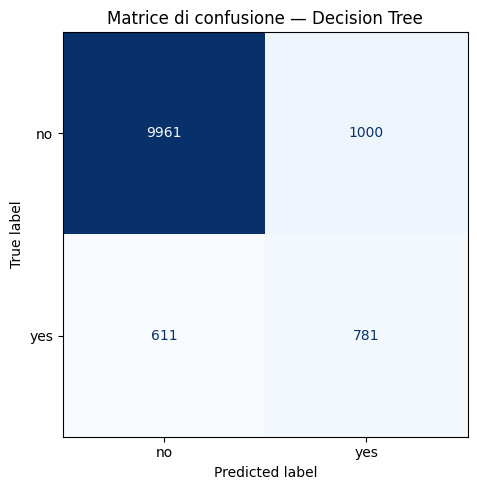


Classification report:

              precision    recall  f1-score   support

          no       0.94      0.91      0.93     10961
         yes       0.44      0.56      0.49      1392

    accuracy                           0.87     12353
   macro avg       0.69      0.73      0.71     12353
weighted avg       0.89      0.87      0.88     12353



In [42]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)

idx_best = tuning["Test_F1"].idxmax()
best_row = tuning.loc[idx_best]

print("=" * 55)
print("  MODELLO SELEZIONATO:", best_row["Model"])
print("=" * 55)
print("  Iperparametri:", best_row["Best_params"])
print(f"  F1 (CV):     {best_row['CV_F1']:.4f}")
print(f"  F1 (test):   {best_row['Test_F1']:.4f}")
print(f"  Recall:      {best_row['Test_Recall']:.4f}")
print(f"  Precision:   {best_row['Test_Precision']:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_row["_pred"], display_labels=["no", "yes"],
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Matrice di confusione — {best_row['Model']}")
plt.tight_layout()
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, best_row["_pred"], target_names=["no", "yes"]))

# 10. Curve di apprendimento

Una **curva di apprendimento**  mostra come varia la prestazione del modello al crescere della **quantità di dati di addestramento**. Lo stesso classificatore viene riaddestrato su porzioni sempre più grandi del training set e, per ogni dimensione, si tracciano due curve: la F1 sul **training** (quanto bene impara i dati visti) e la F1 in **cross-validation** (quanto bene generalizza).

La forma delle due curve, e soprattutto il **gap** tra loro, diagnostica la natura del problema:

- **gap ampio**, training alto e validazione bassa -> *overfitting* (alta varianza): piu dati o piu regolarizzazione aiutano;
- **curve vicine ma entrambe basse** -> *underfitting* (alto bias): il modello e limitato dalle feature disponibili, e piu dati **non** aiutano;
- **curve vicine ed entrambe alte** -> buon compromesso.

Tracciamo la curva per il **modello finale selezionato** (l'Albero ottimizzato), usando `learning_curve` con la stessa cross-validation stratificata a 10 fold e la F1 come metrica. L'obiettivo e capire se il tetto di prestazioni osservato (~0.49 di F1) dipenda dal modello o dai dati.

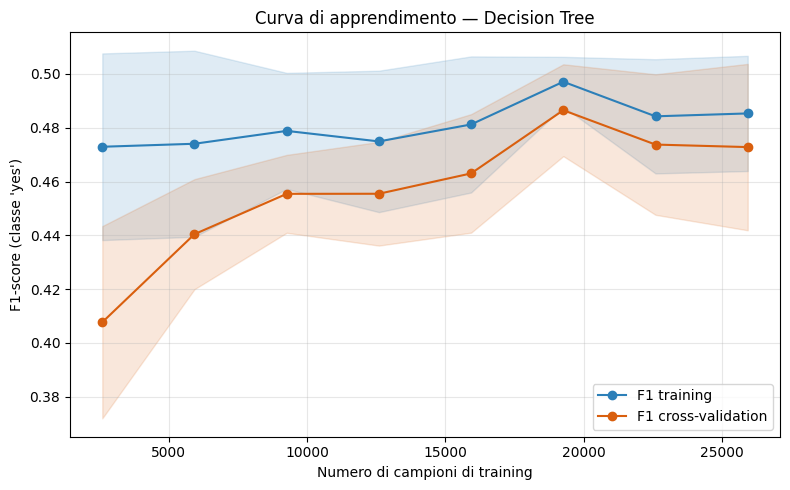

Gap finale training - validazione: 0.0125


In [43]:
from sklearn.model_selection import learning_curve

# Modello finale selezionato nella sezione 9 (pipeline completa gia ottimizzata)
modello_lc = best_row["_estimator"]

train_sizes, train_scores, valid_scores = learning_curve(
    modello_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring="f1",
    shuffle=True, random_state=SEED, n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
valid_mean, valid_std = valid_scores.mean(axis=1), valid_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#2c7fb8", label="F1 training")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#2c7fb8")
ax.plot(train_sizes, valid_mean, "o-", color="#d95f0e", label="F1 cross-validation")
ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std,
                alpha=0.15, color="#d95f0e")
ax.set_xlabel("Numero di campioni di training")
ax.set_ylabel("F1-score (classe 'yes')")
ax.set_title(f"Curva di apprendimento — {best_row['Model']}")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gap finale training - validazione: "
      f"{train_mean[-1] - valid_mean[-1]:.4f}")

### Analisi della curva di apprendimento

La curva mostra un quadro nitido: le due linee — training e cross-validation — sono **molto vicine tra loro** (gap finale di pochi millesimi) e si **appiattiscono presto**, gia intorno agli 8.000 campioni, su un valore di F1 contenuto. Aumentando ulteriormente i dati la validazione **non migliora**.

Questo e il profilo tipico dell'**underfitting (alto bias)**, non dell'overfitting: il modello non sta memorizzando il training (altrimenti il training score sarebbe nettamente piu alto della validazione), ma e **limitato dall'informazione disponibile nelle feature**. La conclusione operativa e duplice:

- **raccogliere piu campioni non aiuterebbe**: il tetto di prestazioni e gia raggiunto con una frazione dei dati;
- il margine di miglioramento va cercato **altrove**: feature piu informative (la rimozione di `duration` per il data leakage ha tolto il predittore piu forte), feature engineering aggiuntivo (Lezione 11), o lo spostamento della soglia decisionale per privilegiare la recall.

In altre parole, la curva conferma che il limite di ~0.49 di F1 e una caratteristica **del dataset** (in condizioni realistiche, senza leakage) e non un difetto del classificatore scelto: e un risultato onesto e ben diagnosticato.